In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import gensim
from pathlib import Path
import sklearn

In [ ]:
dossier_path = Path("/Users/morganrichard/Desktop/Test_Champs_lexcaux/Corpus_textes")

donnees = []

# On boucle sur tous les fichiers .txt du dossier
for fichier in dossier_path.glob("*.txt"):
    with open(fichier, "r", encoding="utf-8") as f:
        contenu = f.read()
        
        # On détermine le label selon le nom du fichier
        label = "naturaliste" if "_N" in fichier.name else "non-naturaliste"
        
        donnees.append({
            "nom_fichier": fichier.name,
            "texte_brut": contenu,
            "label": label
        })

# Création du tableau de bord (DataFrame)
df = pd.DataFrame(donnees)
print(f"{len(df)} textes chargés avec succès.")

10 textes chargés avec succès.


In [7]:
df.head(10)

,nom_fichier,texte_brut,label
0,1883_Lesueur_L'amant-de-Genevieve_A.txt,PREMIÈRE PARTIE Chapitre I. Il y avait bien tr...,non-naturaliste
1,1882_Albalat_L'inassouvie-roman-intime_A.txt,\nLES CHASTETÉS IMPURESPREMIERE PARTIEI.\nJe n...,non-naturaliste
2,1882_Verne_L-Ecole-des-Robinsons_A.txt,"I« Île à vendre, au comptant, frais en sus, au...",non-naturaliste
3,1885_Adam_Chair-molle_N.txt,\n\n\nPaul Adam\n\n\n\nChair molle\n\n\nRoman ...,naturaliste
4,1886_Rosny_Nell-Horn_N.txt,\n\n\n\n\nPREMIÈRE PARTIE\nAu fond de la pelou...,naturaliste
5,1884_Rachilde_Monsieur-Venus_A.txt,RACHILDE MONSIEUR VÉNUS A Monsieur LÉO D'ORF...,non-naturaliste
6,1879_ Goncourt_Les-Freres-Zemganno_N.txt,\n\n\n\nEdmond de Goncourt\n\n\n\nLes Frères Z...,naturaliste
7,1881_Lemmonier_un-mâle_N.txt,\n\nCamille Lemonnier\n\n\n\n\nUn mâle\n\n\n\n...,naturaliste
8,1881_Barbey-d-Aurevilly_Une-histoire-sans-nom_...,"Mon cher Paul Bourget, Je veux mettre votre n...",non-naturaliste
9,1882_Cladel_Ompdrailles_N.txt,\nLéon Cladel.\n\nOmpdrailles le Tombeau-des-L...,naturaliste


In [14]:
# On reprend la fonction de l'étape précédente

nlp = spacy.load("fr_core_news_md")
def preprocess_text(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
    return " ".join(tokens)

# Application magique de Pandas : on nettoie les 10 textes d'un coup
df['texte_propre'] = df['texte_brut'].apply(preprocess_text)

# Regardons le résultat
print(df[['label', 'texte_propre']].head())

             label                                       texte_propre
0  non-naturaliste  partie chapitre bien minute maire achever disc...
1  non-naturaliste  chasteté impurespremier partiei savoir aimer é...
2  non-naturaliste  île vendre comptant frais sus offrir dernier e...
3      naturaliste  paul adam chair mou roman naturaliste partie g...
4      naturaliste  partie fond pelouse lisière massif sombre tota...


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

# --- 1. PREPROCESSING ---
# (On utilise la fonction preprocess_text définie précédemment avec SpaCy)
df['texte_propre'] = df['texte_brut'].apply(preprocess_text)

# --- 2. VECTORISATION (TF-IDF) ---
vectorizer = TfidfVectorizer(max_features=500) # On garde les 500 mots les plus importants
tfidf_matrix = vectorizer.fit_transform(df['texte_propre'])

# --- 3. CLUSTERING (K-Means) ---
# On demande à l'algo de créer 2 groupes (puisqu'on sait qu'on a 2 types de textes)
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)

# --- 4. TOPIC MODELING (LDA) ---
# On cherche à extraire 2 thèmes majeurs du corpus
lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(tfidf_matrix)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",2
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [16]:
# Tableau croisé pour comparer les vrais labels et les clusters trouvés
comparaison = pd.crosstab(df['label'], df['cluster'])
print("--- Comparaison Vrai Label vs Cluster ---")
print(comparaison)

--- Comparaison Vrai Label vs Cluster ---
cluster          0  1
label                
naturaliste      1  4
non-naturaliste  0  5


In [17]:
def afficher_topics(model, vectorizer, n_top_words):
    mots = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(model.components_):
        message = f"Thème #{topic_idx} : "
        message += " | ".join([mots[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

# On affiche les 10 mots principaux pour nos 2 topics
afficher_topics(lda, vectorizer, 10)

Thème #0 : godfrey | tartelett | nelly | raoule | jacques | lasthénie | mmedeferjol | être | raittolbe | faire
Thème #1 : faire | être | bien | voir | avoir | petit | aller | vouloir | venir | jour


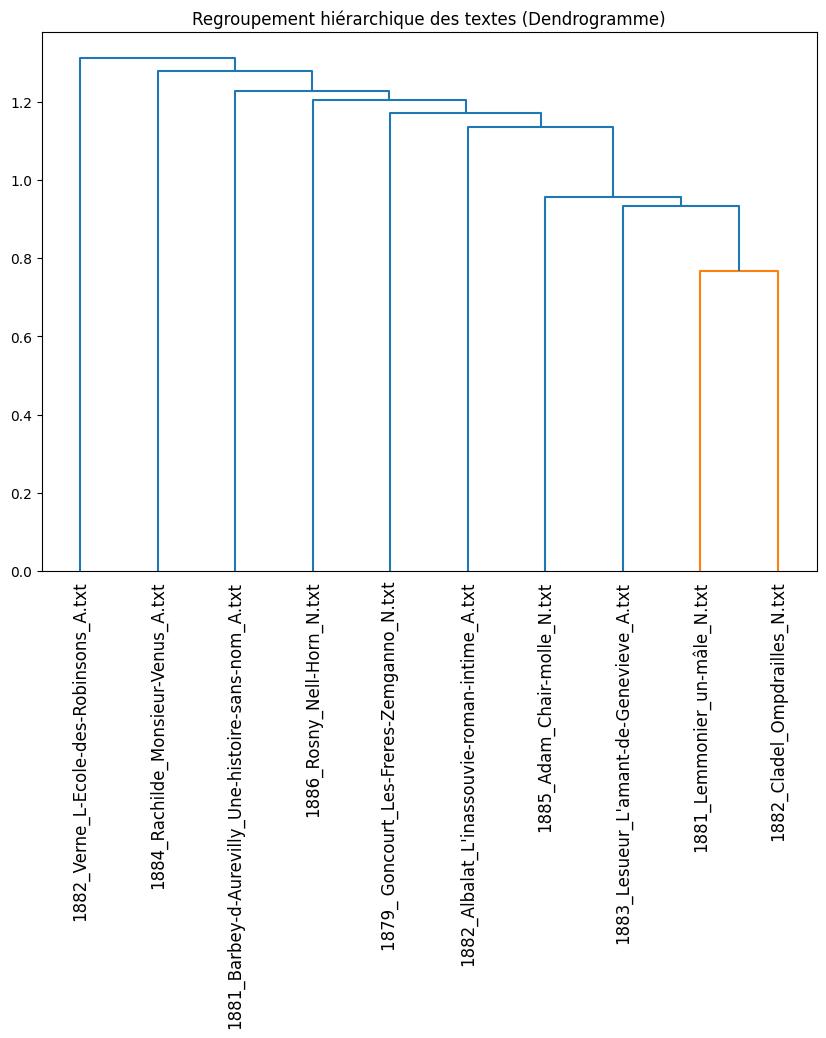

In [18]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# On calcule les distances entre les textes
distances = linkage(tfidf_matrix.toarray(), method='ward')

plt.figure(figsize=(10, 7))
plt.title("Regroupement hiérarchique des textes (Dendrogramme)")
dendrogram(distances, labels=df['nom_fichier'].values, leaf_rotation=90)
plt.show()